In [1]:
import pandas as pd
import numpy as np

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
print(train.head())
print(train.info())

          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   
3                1        -74.010040        40.719971         -74.012268   
4                1        -73.973053        40.793209         -73.972923   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.765602                  N            455  
1         40.731

In [4]:
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])
train['pickup_hour'] = train['pickup_datetime'].dt.hour
train['pickup_day'] = train['pickup_datetime'].dt.dayofweek


In [5]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R * c

train['distance'] = haversine(
    train['pickup_latitude'], train['pickup_longitude'],
    train['dropoff_latitude'], train['dropoff_longitude']
)

In [6]:
train['store_and_fwd_flag'] = train['store_and_fwd_flag'].map({'N':0,'Y':1})

In [7]:
features = ['vendor_id','passenger_count','pickup_hour','pickup_day','distance','store_and_fwd_flag']
X = train[features].values
y = train['trip_duration'].values.reshape(-1,1)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

In [9]:
from sklearn.model_selection import train_test_split
import torch

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

In [24]:
class MLPRegression(nn.Module):
    def __init__(self):
        super(MLPRegression, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(6,128),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(128,64),
            nn.GELU(),

            nn.Linear(64,32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.15),

            nn.Linear(32,1)
        )
    def forward(self,x):
        return self.network(x)

In [25]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [26]:
train_losses = []
val_losses = []

epochs = 50  # or whatever you trained

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

Epoch 5: Train Loss=1.1501, Val Loss=0.3815
Epoch 10: Train Loss=1.1434, Val Loss=0.3771
Epoch 15: Train Loss=1.1427, Val Loss=0.3754
Epoch 20: Train Loss=1.1424, Val Loss=0.3751
Epoch 25: Train Loss=1.1418, Val Loss=0.3750
Epoch 30: Train Loss=1.1418, Val Loss=0.3749
Epoch 35: Train Loss=1.1416, Val Loss=0.3746
Epoch 40: Train Loss=1.1415, Val Loss=0.3744
Epoch 45: Train Loss=1.1414, Val Loss=0.3742
Epoch 50: Train Loss=1.1413, Val Loss=0.3742


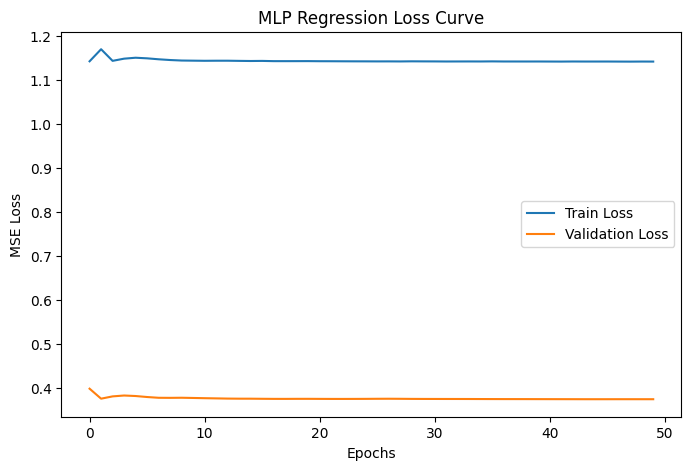

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("MLP Regression Loss Curve")
plt.legend()
plt.show()

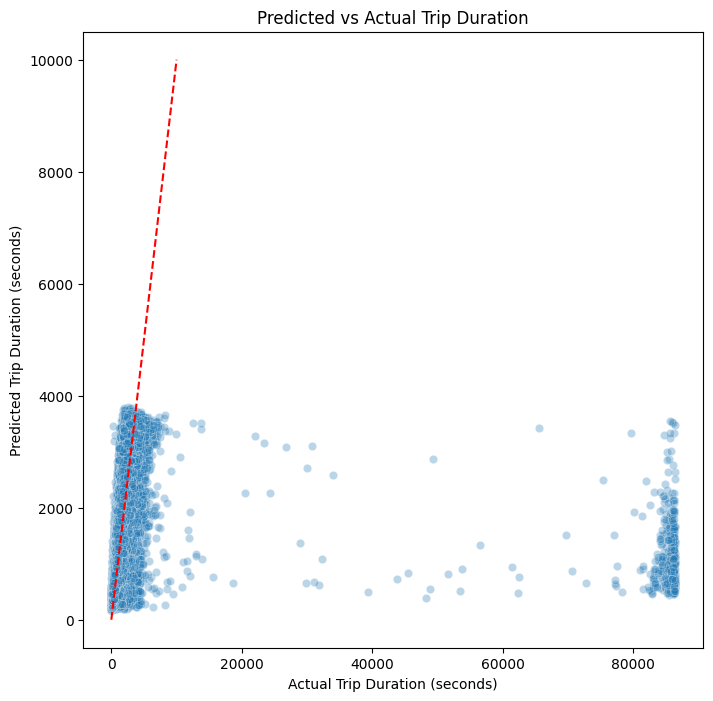

In [28]:
import seaborn as sns
import numpy as np

model.eval()
with torch.no_grad():
    y_val_pred = model(X_val)
    y_val_pred_inv = scaler_y.inverse_transform(y_val_pred.numpy())
    y_val_actual = scaler_y.inverse_transform(y_val.numpy())

plt.figure(figsize=(8,8))
sns.scatterplot(x=y_val_actual.flatten(), y=y_val_pred_inv.flatten(), alpha=0.3)
plt.plot([0, 10000], [0, 10000], 'r--')  # perfect prediction line y=x
plt.xlabel("Actual Trip Duration (seconds)")
plt.ylabel("Predicted Trip Duration (seconds)")
plt.title("Predicted vs Actual Trip Duration")
plt.show()

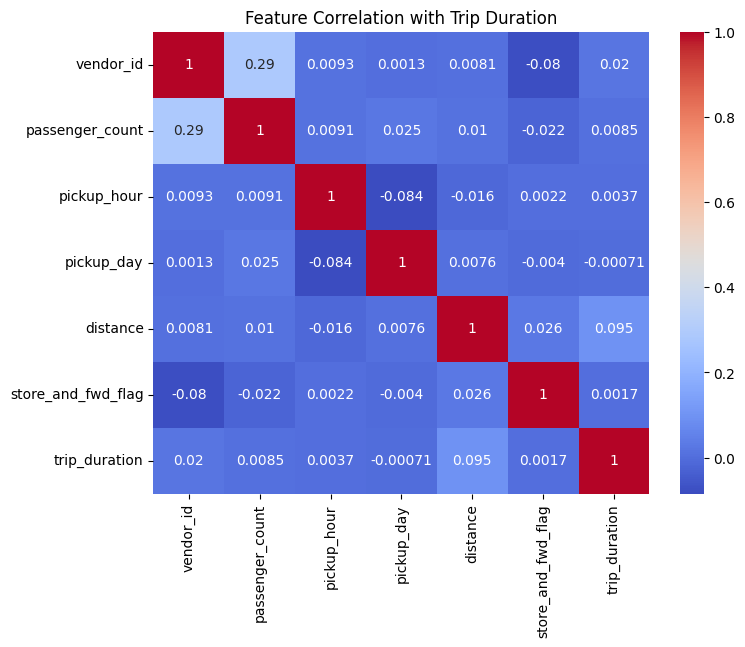

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(train[features + ['trip_duration']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Trip Duration")
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

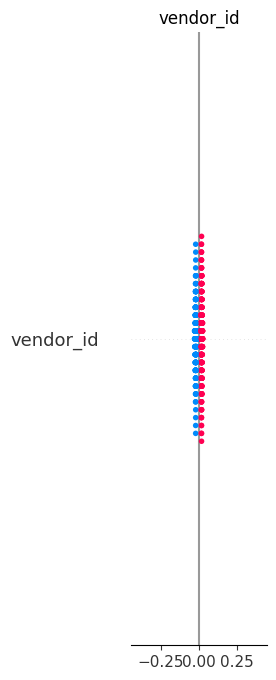

In [37]:
import shap
import torch

# Define a wrapper function for the PyTorch model
def predict_fn(x):
    # Ensure x is a numpy array for this conversion step if it comes from shap
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        output = model(x_tensor).cpu().numpy() # Move to CPU and convert to numpy
    return output

# Use a small sample of training data as background data for SHAP, converted to numpy
background_data = X_train[:500].cpu().numpy()

# Initialize explainer with the wrapper function and background data
explainer = shap.KernelExplainer(predict_fn, background_data)

# Generate SHAP values for the validation set, converted to numpy for the explainer
shap_values = explainer.shap_values(X_val[:500].cpu().numpy())

# Plot the summary, with X_val also converted to numpy
shap.summary_plot(shap_values, X_val[:500].cpu().numpy(), feature_names=features)

In [31]:
# Save PyTorch model weights
torch.save(model.state_dict(), "mlp_taxi_weights.pth")

# Save scalers (input and output)
import joblib
joblib.dump(scaler_X, "scaler_X.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

['scaler_y.pkl']

In [40]:
!pip install streamlit pyngrok

In [53]:
from pyngrok import ngrok

# Set your authtoken
ngrok.set_auth_token("")

In [56]:
import os
from pyngrok import ngrok

# Kill any previous tunnels
ngrok.kill()

# Run Streamlit in background
get_ipython().system_raw("streamlit run app.py --server.port 8501 &")

# Open public URL using ngrok API
public_url = ngrok.connect(8501)
print("Streamlit app is live at:", public_url)

Streamlit app is live at: NgrokTunnel: "https://a3ff-34-125-219-156.ngrok-free.app" -> "http://localhost:8501"


In [57]:
ngrok.disconnect(public_url)
ngrok.kill()